Test with tf savedmodel format model file

In [1]:
! pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.5/16.5 MB 39.2 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
openvino 2024.6.0 requires numpy<2.2.0,>=1.16.6, but you have numpy 2.2.6 which is incompatible.
openvino-dev 2024.6.0 requires numpy<2.0.0,>=1.16.6, but you have numpy 2.2.6 which is incompatible.
spopt 0.7.0 requires networkx>=3.2, but you have networkx 3.1 which is incompatible.
numba 0.60.0 requires numpy<2.1,>=1.22, but you have numpy 2.2.6 which is incompatible.
mapclassify 2.10.0 requires networkx>=3.2, but you have networkx 3.1 which is incompatible.
tensorflow 2.19.0 requires numpy<2.2.0,>=1.26.0, but

In [2]:
import ultralytics
ultralytics.checks()

Ultralytics 8.3.243 🚀 Python-3.12.12 torch-2.9.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 21.2/107.7 GB disk)


In [3]:
import cv2, os
import numpy as np
from PIL import Image
import tensorflow as tf
from ultralytics import YOLO
import matplotlib.pyplot as plt

Loading required models

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
fish_model = YOLO('/content/drive/MyDrive/Sowmya /models/app model versions/Sardine/v5/fish (1).pt')
cuts_damages_model = YOLO("/content/drive/MyDrive/Sowmya /models/app model versions/Sardine/v5/cut-seg.pt")
savedmodel_path = "/content/drive/MyDrive/Sowmya /models/app model versions/Sardine/v5/sardine_model_20epochs_k_gpu"
loaded = tf.saved_model.load(savedmodel_path)
infer = loaded.signatures["serving_default"]
softness_model = infer

In [ ]:
def yolo_results(img_path, model, imgsz=640, conf=0.75, iou=0.7):
    results = model(img_path, imgsz=imgsz, conf=conf, iou=iou, verbose=False)
    return results

cuts and damages utils

In [ ]:
def process_image(image, size=(640, 640)): # for eye model
    h, w = image.shape[:2]
    aspect_ratio = w / h
    if aspect_ratio > 1:
        new_w = size[0]
        new_h = int(new_w / aspect_ratio)
    else:
        new_h = size[1]
        new_w = int(new_h * aspect_ratio)

    resized_image = cv2.resize(image, (new_w, new_h))

    pad_h = (size[1] - new_h) // 2
    pad_w = (size[0] - new_w) // 2
    padded_image = cv2.copyMakeBorder(
        resized_image, pad_h, pad_h, pad_w, pad_w, cv2.BORDER_CONSTANT, value=(255, 255, 255)
    )
    padded_image = cv2.resize(padded_image, (640,640))
    return np.asarray(padded_image)

def cuts_damages(seg_img):
    image = process_image(seg_img)
    image = image[:,:,::-1]
    results = yolo_results(image, cuts_damages_model, conf=0.5, iou=0.7)
    cuts_detected = len(results[0].boxes.cls)
    if cuts_detected == 0:
        return None
    else:
        return True

In [ ]:
def softness_model_predict(seg_img, model):
    img = cv2.resize(seg_img, (224, 224))
    img_array = tf.keras.applications.densenet.preprocess_input(img)
    img_array = tf.expand_dims(img_array, axis=0)
    labeling = infer(img_array)
    pred = 'Good' if labeling['output_0'].numpy()[0][0] >= 0.5 else 'Bad'
    return pred

Drawing bboxes, masks and labels

In [ ]:
def add_text(img, text):
    font = cv2.FONT_HERSHEY_SIMPLEX
    fontScale = 3
    color = (0, 0, 0)
    thickness = 2

    # Using cv2.putText() method
    out_img = cv2.putText(img, text, (10, 30), font, fontScale, color, thickness, cv2.LINE_AA)
    return out_img

def get_segmented_img(pred, white_background=False, index=0):
    img_shape = pred.orig_shape
    img = pred.orig_img.copy()
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    height, width = img_shape[0], img_shape[1]
    masks = pred.masks.xy
    mask = masks[index]
    mask_points = mask.astype(int)
    binary_mask = np.zeros((height, width), dtype=np.uint8)
    cv2.fillPoly(binary_mask, [mask_points], 255)
    masked_img = cv2.bitwise_and(img, img, mask=binary_mask)
    x, y, w, h = cv2.boundingRect(mask_points)
    x1, y1, x2, y2 = (x, y, x+w, y+h)
    box = [x1, y1, x2, y2]
    segment_image = np.zeros((height, width, 3), dtype=np.uint8)
    segment_image[y:y+h, x:x+w] = masked_img[y:y+h, x:x+w]
    segment_image = segment_image[y:y+h, x:x+w]
    # white_background = False
    if white_background:
        black_mask = np.all(segment_image == [0, 0, 0], axis=-1)
        segment_image[black_mask] = [255, 255, 255]
    return segment_image, mask, box

def get_colors(pred_class):
    if pred_class == 'Bad':
        color = (0, 0, 235)
    else:
        color = (0, 235, 0)
    return color

def draw_annotated_boxes(img, box, color, text):
    cv2.rectangle(img, (box[0], box[1]), (box[2], box[3]),
                  color, 5)
    # Define the font and scale of the text
    font = cv2.FONT_HERSHEY_SIMPLEX
    font_scale = 2
    font_color = (255, 255, 255)  # White color
    font_thickness = 5
    text_position = (box[0], box[1] - 10)

    # Get the size of the text to calculate the background rectangle
    (text_width, text_height), baseline = cv2.getTextSize(
                                text, font, font_scale, font_thickness)

    # Calculate the position for the background rectangle
    background_rect_start = (box[0], box[1] - text_height - 10)
    # background_rect_end = (box[0] + text_width, box[1] - baseline + 10)
    background_rect_end = (box[0] + text_width, box[1])

    # Draw the background rectangle
    cv2.rectangle(img, background_rect_start,
                  background_rect_end, color, -1)

    # Put the text on the image
    out_img = cv2.putText(img, text, text_position,
                          font, font_scale, font_color, font_thickness)
    return out_img

def fill_mask(img, mask, color):
    height, width = img.shape[0], img.shape[1]
    binary_mask = np.zeros((height, width), dtype=np.uint8)
    mask = mask.astype(np.int32)
    cv2.fillPoly(binary_mask, [mask], 255)
    # return binary_mask

    masked_img = cv2.bitwise_and(img, img, mask=binary_mask)
    masked_img[binary_mask == 255] = color
    transparency = 0.6
    masked_img = cv2.addWeighted(img, 1.0, masked_img, transparency, 0)
    return masked_img

def draw_bbox_masks_labels(img, mask, box, text, color):
    masked_img = fill_mask(img, mask, color)
    out_img = draw_annotated_boxes(masked_img, box, color, text)
    return out_img

getting final predictions for each image

In [ ]:
def get_result_img(results):
    obj_detected = len(results[0].boxes.cls)
    print(f'Number of fish detected: {obj_detected}')
    if obj_detected == 0:
        # add text 'No fish detected' over the image
        output_img = add_text(results[0].orig_img, 'No fish detected')
        return output_img
    else:
        output_img = results[0].orig_img
        for i in range(obj_detected):
            seg_img, mask, bbox = get_segmented_img(results[0], True, i)
            # Go to Cuts and damages model
            cuts = cuts_damages(seg_img)
            if (cuts==None) or (cuts == False):
                seg_img, mask, bbox = get_segmented_img(results[0], False, i)
                pred = softness_model_predict(seg_img, softness_model)
                color = get_colors(pred)
                text = f'{pred}: Soft'
                if pred == 'Good': text = f'{pred}'
                print(text)
                output_img = draw_bbox_masks_labels(output_img, mask,
                                                    bbox, text, color)
            else:
                pred = 'Bad'
                color = get_colors(pred)
                text = f'{pred}: Cuts'
                print(text)
                output_img = draw_bbox_masks_labels(output_img, mask, bbox,
                                                    text, color)
    return output_img

Number of fish detected: 3
Bad: Soft
Bad: Soft
Bad: Soft


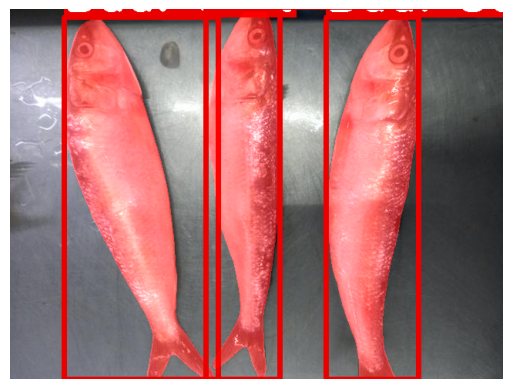

In [ ]:
img_path = "/content/drive/MyDrive/Sowmya /models/app model versions/Sardine/v5/2023-11-23_09_49_41_(2195)_sardine_input.jpeg"
results = yolo_results(img_path, fish_model, conf=0.75, iou=0.7)
output_img = get_result_img(results)
rgb_img = cv2.cvtColor(output_img, cv2.COLOR_BGR2RGB)
plt.imshow(rgb_img);
plt.axis('off');

### New functions to address text display near edges

In [ ]:
def draw_annotated_boxes_v2(img, box, color, text):
    img_height, img_width = img.shape[:2]

    font = cv2.FONT_HERSHEY_SIMPLEX
    font_scale = 0.8 # Slightly reduced font scale for better fit
    font_color = (255, 255, 255)  # White color
    font_thickness = 2
    padding = 2 # Padding around text and background

    # Get the size of the text
    (text_width, text_height), baseline = cv2.getTextSize(
        text, font, font_scale, font_thickness
    )

    # Attempt to place text above the bounding box
    text_x = box[0]
    text_y = box[1] - padding # This is the bottom-most point of the text (baseline)

    # Calculate background rectangle coordinates
    bg_rect_start_x = text_x - padding
    bg_rect_start_y = text_y - text_height - padding # Top of the background
    bg_rect_end_x = text_x + text_width + padding
    bg_rect_end_y = text_y + baseline + padding # Bottom of the background

    # Adjust position if it goes above the image top boundary
    if bg_rect_start_y < 0:
        # Place text inside the bounding box, at the top
        text_y = box[1] + text_height + padding  # New baseline inside the box
        bg_rect_start_y = box[1] # Background starts at the top of the bounding box
        bg_rect_end_y = text_y + baseline + padding # Recalculate end_y

    # Ensure coordinates are within image bounds
    bg_rect_start_x = max(0, bg_rect_start_x)
    bg_rect_start_y = max(0, bg_rect_start_y)
    bg_rect_end_x = min(img_width, bg_rect_end_x)
    bg_rect_end_y = min(img_height, bg_rect_end_y)

    # Draw the main bounding box
    cv2.rectangle(img, (box[0], box[1]), (box[2], box[3]), color, 5)

    # Draw the background rectangle for the text
    cv2.rectangle(img, (bg_rect_start_x, bg_rect_start_y),
                  (bg_rect_end_x, bg_rect_end_y), color, -1)

    # Put the text on the image using the adjusted baseline y-coordinate
    out_img = cv2.putText(img, text, (text_x, text_y),
                          font, font_scale, font_color, font_thickness, cv2.LINE_AA)
    return out_img

def fill_mask_v2(img, mask, color):
    height, width = img.shape[0], img.shape[1]
    binary_mask = np.zeros((height, width), dtype=np.uint8)
    mask = mask.astype(np.int32)
    cv2.fillPoly(binary_mask, [mask], 255)

    masked_img = cv2.bitwise_and(img, img, mask=binary_mask)
    masked_img[binary_mask == 255] = color
    transparency = 0.6
    masked_img = cv2.addWeighted(img, 1.0, masked_img, transparency, 0)
    return masked_img

def draw_bbox_masks_labels_v2(img, mask, box, text, color):
    masked_img = fill_mask_v2(img, mask, color)
    out_img = draw_annotated_boxes_v2(masked_img, box, color, text)
    return out_img

In [ ]:
def get_result_img_v2(results):
    obj_detected = len(results[0].boxes.cls)
    print(f'Number of objects detected: {obj_detected}')
    if obj_detected == 0:
        output_img = add_text(results[0].orig_img.copy(), 'No fish detected')
        return output_img
    else:
        output_img = results[0].orig_img.copy() # Make a copy to avoid modifying original
        for i in range(obj_detected):
            # Get segmented image for cuts_damages (with white background)
            segmented_img_cuts, mask_cuts, bbox_cuts = get_segmented_img(results[0], True, i)
            cuts = cuts_damages(segmented_img_cuts)

            if (cuts is None) or (cuts is False):
                # If no cuts, then predict softness. Get segmented image for softness (with black background)
                segmented_img_softness, mask_softness, bbox_softness = get_segmented_img(results[0], False, i)
                pred = softness_model_predict(segmented_img_softness, softness_model)
                color = get_colors(pred)
                text = f'{pred}: Soft'
                if pred == 'Good': text = f'{pred}'
                print(text)
                output_img = draw_bbox_masks_labels_v2(output_img, mask_softness,
                                                    bbox_softness, text, color)
            else:
                pred = 'Bad'
                color = get_colors(pred)
                text = f'{pred}: Cuts'
                print(text)
                output_img = draw_bbox_masks_labels_v2(output_img, mask_cuts, bbox_cuts,
                                                    text, color)
    return output_img

### Running with the new functions

Number of objects detected: 3
Bad: Soft
Bad: Soft
Bad: Soft


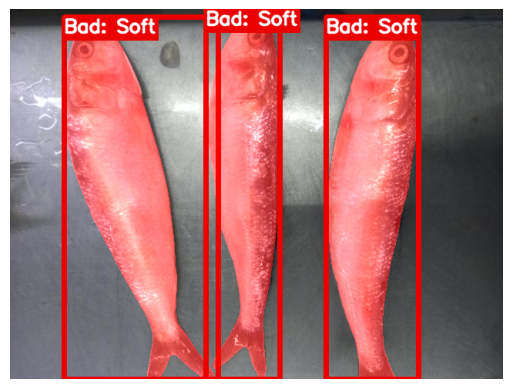

In [ ]:
img_path = "/content/drive/MyDrive/Sowmya /models/app model versions/Sardine/v5/2023-11-23_09_49_41_(2195)_sardine_input.jpeg"
results = yolo_results(img_path, fish_model, conf=0.75, iou=0.7)
output_img_v2 = get_result_img_v2(results)
rgb_img_v2 = cv2.cvtColor(output_img_v2, cv2.COLOR_BGR2RGB)
plt.imshow(rgb_img_v2);
plt.axis('off');

Number of objects detected: 2
Bad: Cuts
Bad: Cuts


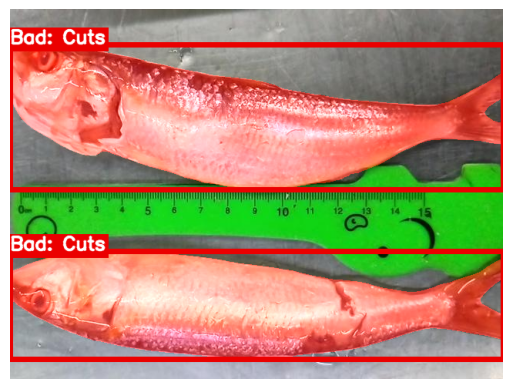

In [ ]:
img_path = "/content/drive/MyDrive/Sowmya /input/2024-12-03/sardine/Bad/2024-12-03_10_14_57_(17680)_sardine_input.jpeg"
results = yolo_results(img_path, fish_model, conf=0.75, iou=0.7)
output_img_v2 = get_result_img_v2(results)
rgb_img_v2 = cv2.cvtColor(output_img_v2, cv2.COLOR_BGR2RGB)
plt.imshow(rgb_img_v2);
plt.axis('off');

In [ ]:
import pandas as pd
def get_results_with_reason(results):
    obj_detected = len(results[0].boxes.cls)
    if obj_detected == 0:
        return 'No fish detected', 'No fish detected'
    else:
        preds=[]
        reasons=[]
        output_img = results[0].orig_img.copy() # Make a copy to avoid modifying original
        for i in range(obj_detected):
            # Get segmented image for cuts_damages (with white background)
            segmented_img_cuts, mask_cuts, bbox_cuts = get_segmented_img(results[0], True, i)
            cuts = cuts_damages(segmented_img_cuts)

            if (cuts is None) or (cuts is False):
                # If no cuts, then predict softness. Get segmented image for softness (with black background)
                segmented_img_softness, mask_softness, bbox_softness = get_segmented_img(results[0], False, i)
                pred = softness_model_predict(segmented_img_softness, softness_model)
                reason = 'Soft'
                if pred == 'Good': reason = 'Good'
            else:
                pred = 'Bad'
                reason = 'Cuts'
            preds.append(pred)
            reasons.append(reason)
        return preds, reasons

from tqdm import tqdm
def get_df_for_folder(single_folder_path):
    data = []
    for filename in tqdm(os.listdir(single_folder_path)):
        img_path = os.path.join(single_folder_path, filename)
        if not os.path.isfile(img_path): continue
        results = yolo_results(img_path, fish_model, conf=0.75, iou=0.7)
        pred, reason = get_results_with_reason(results)
        filenames=[filename]*len(pred)
        data.append([filenames, pred, reason])

    # Create lists for each column
    filename_list = []
    pred_list = []
    reason_list = []

    # Iterate through the nested list and extract values
    for sublist in data:
        filename_list.extend(sublist[0])
        pred_list.extend(sublist[1])
        reason_list.extend(sublist[2])

    new_df = pd.DataFrame({'filename': filename_list,
                           'pred': pred_list,
                           'reason': reason_list})
    return new_df

def test_multiple_folders(folder_path):
    dfs=[]
    for date in os.listdir(folder_path):
        species_folder_path = os.path.join(folder_path, date, 'sardine')
        if not os.path.isdir(species_folder_path): continue
        for folder in os.listdir(species_folder_path):
            single_folder_path = os.path.join(species_folder_path, folder)
            new_df = get_df_for_folder(single_folder_path)
            new_df['actual'] = folder
            # new_df['Date'] = new_df['filename'].str[:10]
            dfs.append(new_df)
    return pd.concat(dfs)

folder_path = "/content/drive/MyDrive/Sowmya /input"
ndf = test_multiple_folders(folder_path)
ndf

100%|██████████| 54/54 [04:31<00:00,  5.03s/it]


,filename,pred,reason,actual
0,2025-01-21_10_16_46_(18770)_sardine_input.jpeg,Good,Good,Good
1,2025-01-21_10_16_46_(18770)_sardine_input.jpeg,Good,Good,Good
2,2025-01-21_10_22_30_(18795)_sardine_input.jpeg,Good,Good,Good
3,2025-01-21_10_22_30_(18795)_sardine_input.jpeg,Good,Good,Good
4,2025-01-21_10_18_01_(18776)_sardine_input.jpeg,Good,Good,Good
...,...,...,...,...
103,2024-12-26_09_29_11_(18171)_sardine_input.jpeg,Good,Good,Good
104,2024-12-26_09_35_47_(18207)_sardine_input.jpeg,Good,Good,Good
105,2024-12-26_09_35_47_(18207)_sardine_input.jpeg,Good,Good,Good
106,2024-12-26_09_31_08_(18177)_sardine_input.jpeg,Good,Good,Good


In [ ]:
ndf.to_csv("/content/drive/MyDrive/Sowmya /input/local_test_reults.csv", index=False)

In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import itertools

def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

    plt.figure(figsize=(6, 4))
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="black" if cm[i, j] > thresh else "red")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.show()

Classification Report:

              precision    recall  f1-score   support

         Bad       0.66      0.66      0.66       476
        Good       0.80      0.81      0.81       835

    accuracy                           0.75      1311
   macro avg       0.73      0.73      0.73      1311
weighted avg       0.75      0.75      0.75      1311

Confusion matrix, without normalization


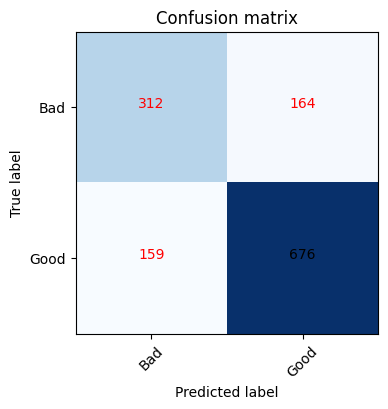

In [ ]:
new_df = ndf
# new_df = temp
predictions = new_df['pred'].values
true_labels = new_df['actual'].values
predictions = np.array(predictions)
true_labels = np.array(true_labels)
print("Classification Report:\n")
print(classification_report(true_labels, predictions, target_names=['Bad', 'Good']))
cnf_matrix = confusion_matrix(true_labels, predictions)
plot_confusion_matrix(cnf_matrix, classes=['Bad', 'Good'])

In [1]:
# import pickle
import cv2
import numpy as np
from keras.models import load_model
import tensorflow as tf
import openvino as ov
import logging

# Initialize OpenVINO Core
core = ov.Core()

logger = logging.getLogger('prediction')

try:
    ov_model = core.read_model(r"/content/drive/MyDrive/Sowmya /models/app model versions/Sardine/latest app test/sardine/sardine.xml")
    ov_model.reshape({ov_model.inputs[0]: [1, 224, 224, 3]})
    model = ov.compile_model(ov_model)
except:
    model = load_model(r"/content/drive/MyDrive/Sowmya /models/app model versions/Sardine/latest app test/sardine/sardine.xml")

target_size = (224, 224)
threshold = 0.5 # 0.478963


def inference_ov_async(infer_request, image):
    """
    Set the input tensor data using the provided image (converted to numpy),
    start asynchronous inference, wait for completion, and return the prediction.
    """
    input_tensor = infer_request.get_input_tensor()
    input_tensor.data[:] = image  # Convert TensorFlow tensor to numpy array
    infer_request.start_async()
    infer_request.wait()  # Wait for inference to complete
    return infer_request.get_output_tensor().data[0][0]

def inference_model(model, image):
    """
    Perform inference using asynchronous mode if OpenVINO is used; otherwise, fall back to synchronous inference.
    """
    output_layer_name = list(model.outputs[0].names)[0]
    try:
        # Use the asynchronous inference approach using the first request
        prediction = inference_ov_async(model.create_infer_request(), image)
        print("With ASYNC inference")
    except:
        print("Using synchronous inference")
        result = model(image)
        prediction = result[output_layer_name][0][0]
    return prediction

def process_image(image):
    """
    Resize and preprocess the input image.
    """
    resized_image = cv2.resize(image, target_size)
    processed_image = tf.keras.applications.densenet.preprocess_input(resized_image)
    processed_image = tf.expand_dims(processed_image, axis=0)
    return processed_image

def predict_sardine(image):
    """
    Process the input image, run inference, and return a label based on the threshold.
    """
    processed = process_image(image)
    logger.info("Sardine Image Processed!")
    pred = inference_model(model, processed)
    label = 'Good' if pred >= threshold else 'Bad'
    logger.info(f"Sardine Model Predicted --> Prediction: Label: {label} , Confidence : {pred}")
    return label

# At the end of sardine.py and prawns.py
dummy_image = np.zeros((1, 224, 224, 3), dtype=np.float32)
try:
    inference_model(model, dummy_image)
    print("✅ Sardine model warm-up complete.")
    logger.info("Sardine model warm-up complete.")
except Exception as e:
    print(f"Error during warm-up: {e}")
    logger.error(f"Error during warm-up: {e}")

With ASYNC inference
✅ Sardine model warm-up complete.


In [3]:
import numpy as np
from PIL import Image
import cv2
import tensorflow as tf
from keras.models import load_model
import base64
from ultralytics import YOLO
import logging
from logging.handlers import RotatingFileHandler
import io

## Openvino models
yolo = YOLO(r'/content/drive/MyDrive/Sowmya /models/app model versions/Sardine/latest app test/best_openvino_model', task='segment')
cut = YOLO(r'/content/drive/MyDrive/Sowmya /models/app model versions/Sardine/latest app test/cut-seg_openvino_model',task='segment')

## Pytorch models
yolo = YOLO('/content/drive/MyDrive/Sowmya /models/app model versions/Sardine/v5/fish (1).pt')
cut = YOLO("/content/drive/MyDrive/Sowmya /models/app model versions/Sardine/v5/cut-seg.pt")


savedmodel_path = "/content/drive/MyDrive/Sowmya /models/app model versions/Sardine/v5/sardine_model_20epochs_k_gpu"
loaded = tf.saved_model.load(savedmodel_path)
infer = loaded.signatures["serving_default"]
softness_model = infer

dummy_image = np.zeros((640, 640, 3), dtype=np.uint8)
yolo.predict(dummy_image, verbose=False)
cut.predict(dummy_image, verbose=False)
print("✅ YOLO detection models warm-up complete.")

def extract_single_image_segment(img, mask_segment, shape, background='black'):
    height, width = shape[0], shape[1]
    segment = np.array(mask_segment, dtype=np.int32)
    segment = segment.reshape((-1, 2))
    mask = np.zeros((height, width), dtype=np.uint8)
    cv2.fillPoly(mask, [segment], 255)
    masked_img = cv2.bitwise_and(img, img, mask=mask)
    x, y, w, h = cv2.boundingRect(segment)
    segment_image = np.zeros((h, w, 3), dtype=np.uint8)
    segment_image[0:h, 0:w] = masked_img[y:y+h, x:x+w]

    if background.lower() == 'black':
        black_mask = np.all(segment_image == [0, 0, 0], axis=-1)
        segment_image[black_mask] = [0, 0, 0]  # Set background to black
        logger.info("Extracted segment with black background.")
    elif background.lower() == 'white':
        black_mask = np.all(segment_image == [0, 0, 0], axis=-1)
        segment_image[black_mask] = [255, 255, 255]  # Set background to white
        logger.info("Extracted segment with White background.")
    else:
        logger.error("Invalid background color specified for segmentation model.")
        raise ValueError("Invalid background color. Use 'black' or 'white'.")

    return segment_image

def process_image2(image, size=(640, 640)): # for eye model
    logger.info("Pre-processing image for damage detection model.")
    h, w = image.shape[:2]
    aspect_ratio = w / h
    if aspect_ratio > 1:
        new_w = size[0]
        new_h = int(new_w / aspect_ratio)
    else:
        new_h = size[1]
        new_w = int(new_h * aspect_ratio)

    resized_image = cv2.resize(image, (new_w, new_h))
    logger.debug(f"Image resized to {new_w}x{new_h}.")

    pad_h = (size[1] - new_h) // 2
    pad_w = (size[0] - new_w) // 2
    padded_image = cv2.copyMakeBorder(
        resized_image, pad_h, pad_h, pad_w, pad_w, cv2.BORDER_CONSTANT, value=(255, 255, 255)
    )
    padded_image = cv2.resize(padded_image, (640,640))
    logger.debug("Image padded and resized to 640x640.")
    return np.asarray(padded_image)


def is_cut(image, conf=0.5):
    img = image[:,:,::-1]
    res = cut.predict(img, conf=conf)
    if len(res[0].boxes.xyxy) == 0:
        logger.info("No Damage Detected.")
        return False
    else:
        logger.info("Fish is Damaged.")
        return True

def return_mask(image, masks, labels, boxes):
    logger.info("Generating output image - Applying masks and labels to the predicted image.")
    # Ensure the image is writable by creating a copy
    writable_image = np.copy(image)

    mask_image = np.zeros_like(writable_image)

    height, width, _ = writable_image.shape

    for mask, label, box in zip(masks, labels, boxes):
        xmin, ymin, xmax, ymax = list(map(int, box))

        # Calculate the thickness and text size based on image dimensions
        thickness = max(int(min(height, width) / 200), 1)
        text_size = max(int(min(height, width) / 800), 1)

        if 'good' in label.lower():
            color = (0, 255, 0)  # Green mask
        elif 'ok' in label.lower():
            color = (255, 255, 0)  # Yellow mask
        else:
            color = (255, 0, 0)  # Red mask

        mask_coords = np.array(mask, dtype=np.int32)
        cv2.fillPoly(mask_image, [mask_coords], color)
        cv2.rectangle(writable_image, (xmin, ymin), (xmax, ymax), color, thickness)
        cv2.putText(writable_image, label, (xmin, ymin - 10), cv2.FONT_HERSHEY_SIMPLEX, text_size, color, thickness)

    alpha = 0.2  # Transparency level for the mask
    image_with_masks = cv2.addWeighted(writable_image, 1 - alpha, mask_image, alpha, 0)
    image_with_masks = cv2.cvtColor(image_with_masks, cv2.COLOR_BGR2RGB)
    return image_with_masks


def freshness_prediction(image, w_mask_image, b_mask_image, fish, box):
    """
    Predict the freshness of a fish based on its appearance and characteristics.

    Args:
    - image: Original image containing the fish.
    - w_mask_image: Image segment with white background.
    - b_mask_image: Image segment with black background.
    - fish: Species of the fish.
    - box: Bounding box coordinates of the fish.

    Returns:
    - label: Freshness label ('Good' or 'Bad').
    - reason: Reason for the freshness label, if any.
    """
    # Check the species of the fish and perform freshness prediction accordingly
    damage = is_cut(process_image2(w_mask_image), conf=0.85)
    if damage:
        logger.info("Sardine is damaged.")
        return 'Bad', 'Damaged'

    # Predict freshness based on sardine-specific model
    pred = predict_sardine(b_mask_image)
    if pred == 'Bad':
        logger.info(f"Sardine freshness prediction: {pred}.")
        return pred, 'Softness'
    else:
        logger.info(f"Sardine freshness prediction: {pred}.")
        return pred, None


def final_prediction(image, species, model):
    """
    Perform final prediction on the given image for a specific species using a specified model.

    Args:
    - image: Image file path or image data (numpy array).
    - species: Species label for classification.
    - model: Model name ('fish' or 'prawn').

    Returns:
    - result: A dictionary containing the prediction results.
    """
    result = dict()
    top3 = []

    # Open image and convert it to numpy array
    img = Image.open(image)
    if img.mode != 'RGB':
        img = img.convert('RGB')
    img_byte_arr = io.BytesIO()
    img.save(img_byte_arr, format=img.format)
    img_byte_arr = img_byte_arr.getvalue()
    img_from_bytes = Image.open(io.BytesIO(img_byte_arr))
    image = np.asarray(img_from_bytes)
    shape = image.shape

    # Perform object detection based on model
    if model.lower() == 'fish':
        pred = yolo.predict(image[:, :, ::-1], conf=0.75)
        logger.info(f"{model.title()} detection completed.")
        if len(pred[0].boxes.xyxy) == 0 : #or len(pred2[0].boxes.xyxy)==0
            logger.warning("No boxes or masks detected in the image.")
            logger.info(f"\n {'#'*150} \n")
            return None

    # Extract bounding boxes and masks
    boxes = pred[0].boxes.xyxy
    masks = pred[0].masks.xy
    filtered_boxes = sorted(boxes, key=lambda bbox: bbox[0])
    sorted_masks = [masks[i] for i in sorted(range(len(masks)), key=lambda x: boxes[x][0])]

    new_labels = []
    reasons = []
    i = 0

    # Iterate over each detected box and mask
    for box, mask in zip(filtered_boxes, sorted_masks):
        i += 1
        xmin, ymin, xmax, ymax = list(map(int, box))
        extracted_image = image[ymin:ymax, xmin:xmax]

        # Perform freshness prediction
        w_mask_image = extract_single_image_segment(image, mask, shape=shape, background='white')
        b_mask_image = extract_single_image_segment(image, mask, shape=shape, background='black')
        L, R = freshness_prediction(image, w_mask_image, b_mask_image, species, box)

        # Construct label for the prediction
        v = str(i) + '-' + str(L)
        if R is not None:
            v += '-' + str(R)
        reasons.append(R)
        new_labels.append(v)

        logger.info(f"Prediction for fish {i}: {v}")

    # Generate output image with labels
    output_image = return_mask(image, sorted_masks, new_labels, filtered_boxes)
    _, image_bytes = cv2.imencode('.jpg', output_image)
    encoded_string = base64.b64encode(image_bytes).decode('utf-8')
    logger.info(f"Output image encoded to 'base64 utf-8' string format")

    # Count good and bad predictions
    good = 0
    bad = 0
    for i in range(len(new_labels)):
        fresh = new_labels[i].split('-')[1]
        top3.append(fresh)
        if fresh.lower() == 'good':
            good += 1
        else:
            bad += 1

    # Construct result dictionary
    result['fishes-detected'] = good + bad
    result['good-fishes'] = good
    result['bad-fishes'] = bad
    result['reasons'] = reasons
    result['image-encode'] = encoded_string
    result['classification'] = 'True'
    result['species'] = species
    result['first3'] = top3

    logger.info(f"Final prediction results: Fishes detected:{good+bad} for species {species}, Good fishes:{good} and Bad fishes: {bad}, Reasons: {reasons} \n")

    return result

Loading /content/drive/MyDrive/Sowmya /models/app model versions/Sardine/latest app test/best_openvino_model for OpenVINO inference...
Using OpenVINO LATENCY mode for batch=1 inference on CPU...
Loading /content/drive/MyDrive/Sowmya /models/app model versions/Sardine/latest app test/cut-seg_openvino_model for OpenVINO inference...
Using OpenVINO LATENCY mode for batch=1 inference on CPU...
✅ YOLO detection models warm-up complete.


In [4]:
image_path = "/content/drive/MyDrive/Sowmya /input/2024-12-03/sardine/Good/2024-12-03_10_04_32_(17678)_sardine_input.jpeg"
final_result = final_prediction(image_path, species='sardine', model='fish')
print(final_result)

With ASYNC inference
With ASYNC inference
{'fishes-detected': 2, 'good-fishes': 2, 'bad-fishes': 0, 'reasons': [None, None], 'image-encode': '...', 'classification': 'True', 'species': 'sardine', 'first3': ['Good', 'Good']}
